### Simulacion de Procesos Financieros
**Andre Esteban Vera - 745232**
19/08/2026

## Clase 5 - Simulación de precios AAPL con Movimiento Browniano Geométrico

**Objetivo:** estimar $\mu$ y $\sigma$ con datos de entrenamiento y simular
10,000 precios posibles al 1 de julio de 2026.

$$S_T = S_0 \exp\left[\left(\mu - \tfrac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\,Z\right]$$

## 1. Librerias

In [37]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Descargar datos

In [38]:
ticker = "AAPL"
inicio = "2026-01-01"
fin    = "2026-08-31"

data = yf.download(ticker, start=inicio, end=fin, auto_adjust=True, progress=False)

data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.274353,277.085800,268.269799,271.520960,37838100
2026-01-05,266.534546,270.773009,265.417591,269.905376,45647200
2026-01-06,261.647827,266.823742,261.408488,266.275247,52352100
2026-01-07,259.623322,262.964234,259.104744,262.485556,48309800
2026-01-08,258.336823,258.586144,255.005878,256.322286,50419300


In [39]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

precios = data['Close']

print(f"Observaciones : {len(precios)}")
print(f"Periodo       : {precios.index[0].date()} a {precios.index[-1].date()}")
precios.head()

Observaciones : 165
Periodo       : 2026-01-02 a 2026-08-28


Date
2026-01-02    270.274353
2026-01-05    266.534546
2026-01-06    261.647827
2026-01-07    259.623322
2026-01-08    258.336823
Name: Close, dtype: float64

## 3. Train-test split

In [40]:
corte_train = "2026-04-30" # 4 meses de entrenamiento
corte_test  = "2026-06-30"  # 2 meses de prueba

train = precios.loc[:corte_train]
test  = precios.loc["2026-05-01":corte_test]

print(f"TRAIN : {train.index[0].date()} a {train.index[-1].date()}  ({len(train)} días)")
print(f"TEST  : {test.index[0].date()} a {test.index[-1].date()}  ({len(test)} días)")
print(f"S_0 (último precio de train) : {train.iloc[-1]:.2f}")

TRAIN : 2026-01-02 a 2026-04-30  (82 días)
TEST  : 2026-05-01 a 2026-06-30  (41 días)
S_0 (último precio de train) : 270.87


## 4. Estimar media y volatilidad

In [41]:
# Rendimientos logarítmicos del set de entrenamiento
log_ret = np.log(train / train.shift(1)).dropna()

mu_diario    = log_ret.mean()
sigma_diaria = log_ret.std()

# Anualizar (252 días hábiles)
mu_log = mu_diario * 252
sigma  = sigma_diaria * np.sqrt(252)
mu     = mu_log + 0.5*sigma**2  #drifttt

print(f"Rendimiento log diario   : {mu_diario:.6f}")
print(f"Volatilidad diaria       : {sigma_diaria:.6f}")
print(f"\n--- Anualizados: ---")
print(f"Volatilidad (σ)          : {sigma:.4f}   ({sigma*100:.2f}%)")
print(f"Drift aritmético (μ)     : {mu:.4f}   ({mu*100:.2f}%)")

Rendimiento log diario   : 0.000027
Volatilidad diaria       : 0.015640

--- Anualizados: ---
Volatilidad (σ)          : 0.2483   (24.83%)
Drift aritmético (μ)     : 0.0376   (3.76%)


## 5. Simular 1,000,000 precios al 1 de julio 2026

In [42]:
S0 = float(train.iloc[-1])
M  = 1_000_000

# Horizonte: días habiles entre fin de train y el 1 de julio
dias = len(precios.loc["2026-05-01":"2026-07-01"])
T = dias / 252

print(f"S_0 : {S0:.2f}")
print(f"Días hábiles hasta el 1-jul : {dias}")
print(f"T (años) : {T:.4f}\n")

Z = np.random.normal(0, 1, M)
ST = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

print(f"Media simulada : {ST.mean():.2f}")
print(f"Mínimo / Máximo : {ST.min():.2f} / {ST.max():.2f}")
print(f"IC 95% : [{np.percentile(ST, 2.5):.2f}, {np.percentile(ST, 97.5):.2f}]")

S_0 : 270.87
Días hábiles hasta el 1-jul : 42
T (años) : 0.1667

Media simulada : 272.53
Mínimo / Máximo : 166.21 / 435.73
IC 95% : [222.24, 330.72]


## 6. Comparar con el precio real

In [43]:
real = float(precios.loc[:"2026-07-01"].iloc[-1])
percentil = (ST < real).mean() * 100

print(f"Precio real al 1-jul : {real:.2f}")
print(f"Media simulada : {ST.mean():.2f}")
print(f"Error : {abs(real - ST.mean()):.2f}  ({abs(real-ST.mean())/real*100:.2f}%)")
print(f"Percentil del real : {percentil:.1f}")
print(f"Dentro del IC 95%? : {np.percentile(ST,2.5) <= real <= np.percentile(ST,97.5)}")

Precio real al 1-jul : 294.13
Media simulada : 272.53
Error : 21.60  (7.34%)
Percentil del real : 78.9
Dentro del IC 95%? : True


## 7. Histograma

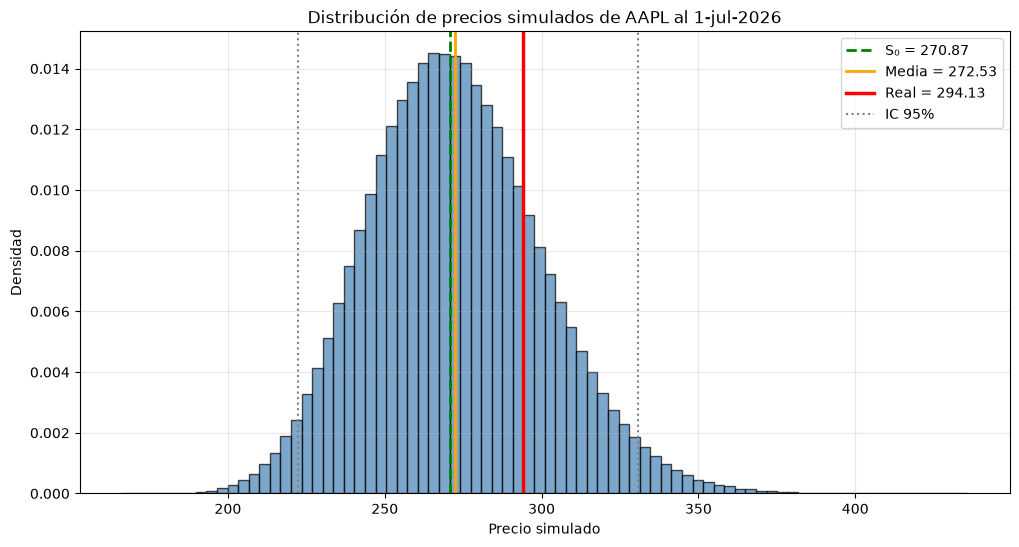

In [44]:
plt.hist(ST, bins=80, density=True, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(S0,        color='green',  ls='--', lw=2, label=f'S₀ = {S0:.2f}')
plt.axvline(ST.mean(), color='orange', ls='-',  lw=2, label=f'Media = {ST.mean():.2f}')
plt.axvline(real,      color='red',    ls='-',  lw=2.5, label=f'Real = {real:.2f}')
plt.axvline(np.percentile(ST, 2.5),  color='gray', ls=':', lw=1.5)
plt.axvline(np.percentile(ST, 97.5), color='gray', ls=':', lw=1.5, label='IC 95%')
plt.xlabel('Precio simulado')
plt.ylabel('Densidad')
plt.title('Distribución de precios simulados de AAPL al 1-jul-2026')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Train vs test vs simulación

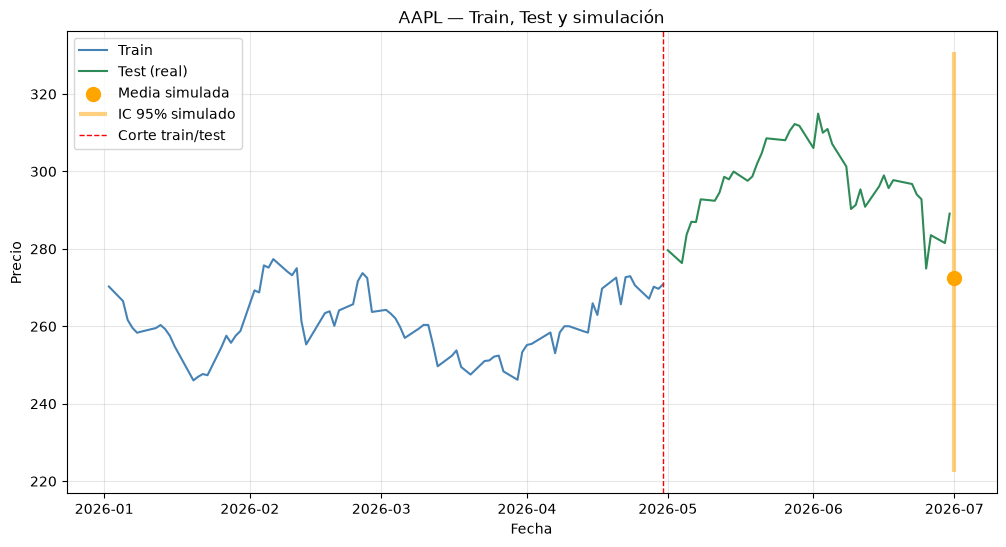

In [45]:
plt.plot(train.index, train.values, color='steelblue', lw=1.5, label='Train')
plt.plot(test.index,  test.values,  color='seagreen',  lw=1.5, label='Test (real)')

fecha_pred = precios.loc[:"2026-07-01"].index[-1]
plt.scatter(fecha_pred, ST.mean(), color='orange', s=100, zorder=5, label='Media simulada')
plt.vlines(fecha_pred, np.percentile(ST,2.5), np.percentile(ST,97.5),
           color='orange', lw=3, alpha=0.5, label='IC 95% simulado')

plt.axvline(train.index[-1], color='red', ls='--', lw=1, label='Corte train/test')
plt.xlabel('Fecha'); plt.ylabel('Precio')
plt.title('AAPL — Train, Test y simulación')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 9. Peor y mejor escenario que aceptaria

Para nosotros, nuestro peor escenario razonable que aceptariamos seria el limite inferior de un intervalo de confianza al 95%, y el mejor escensario razonable el limite superior.

In [46]:
print(f"IC 95% : [{np.percentile(ST, 2.5):.2f}, {np.percentile(ST, 97.5):.2f}]")
print(f"Limite inferior (peor caso razonable): {np.percentile(ST, 2.5):.2f}")
print(f"Limite superior (mejor caso razonable): {np.percentile(ST, 97.5):.2f}")

print(f"precio real : {real:.2f}")
print(f"precio al 30-abr : {precios.loc['2026-04-30']:.2f}")

IC 95% : [222.24, 330.72]
Limite inferior (peor caso razonable): 222.24
Limite superior (mejor caso razonable): 330.72
precio real : 294.13
precio al 30-abr : 270.87
